<a href="https://colab.research.google.com/github/444112029012/phishing-detection-project/blob/main/colab/%E5%BB%BA%E7%AB%8B%E5%9F%BA%E6%A8%A1%E5%9E%8B%20/URL_model/Model_URL_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df  = pd.read_csv('/content/phishing_dataset_combine2_url.csv')
df.drop('url', axis=1, inplace=True)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147225 entries, 0 to 147224
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   target              147225 non-null  int64  
 1   length_url          147225 non-null  int64  
 2   length_hostname     147225 non-null  int64  
 3   ip                  147225 non-null  int64  
 4   nb_dots             147225 non-null  int64  
 5   nb_hyphens          147225 non-null  int64  
 6   nb_at               147225 non-null  int64  
 7   nb_qm               147225 non-null  int64  
 8   nb_and              147225 non-null  int64  
 9   nb_or               147225 non-null  int64  
 10  nb_eq               147225 non-null  int64  
 11  nb_underscore       147225 non-null  int64  
 12  nb_tilde            147225 non-null  int64  
 13  nb_percent          147225 non-null  int64  
 14  nb_slash            147225 non-null  int64  
 15  nb_star             147225 non-nul

,target,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,length_words_raw,char_repeat,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path
0,1,30,22,0,2,0,0,0,0,0,...,25,1,3,0,14,14,0,6.250000,6.666667,0.0
1,0,25,18,0,2,0,0,0,0,0,...,20,1,3,0,10,10,0,5.000000,5.333333,0.0
2,1,24,16,0,2,0,0,0,0,0,...,19,1,2,0,9,9,0,4.750000,4.666667,0.0
3,1,28,20,0,2,0,0,0,0,0,...,23,1,3,0,12,12,0,5.750000,6.000000,0.0
4,0,28,11,0,1,0,0,0,0,0,...,23,1,3,8,8,7,8,5.750000,5.000000,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147220,1,30,22,0,2,0,0,0,0,0,...,25,1,3,0,14,14,0,6.250000,6.666667,0.0
147221,1,29,21,0,3,0,0,0,0,0,...,23,1,2,0,10,10,0,4.600000,4.500000,0.0
147222,1,31,23,0,2,0,0,0,0,0,...,26,1,2,0,16,16,0,6.500000,7.000000,0.0
147223,0,56,47,0,3,2,0,0,0,0,...,47,1,3,0,17,17,0,6.714286,7.000000,0.0


# **基礎設定與基礎設定與 Preprocessor**

In [ ]:
%%capture
!pip install optuna

In [ ]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# 讓 Optuna 安靜一點，不要瘋狂洗版輸出
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 假設 df 已經準備好
X = df.drop("target", axis=1)
y = df["target"]

print(f"特徵數量: {X.shape[1]}, 樣本總數: {X.shape[0]}")

# 1. ColumnTransformer 設定 (部分欄位標準化)
passthrough_cols = [
    "ip", "http_in_path", "https_token", "punycode", "port",
    "tld_in_path", "tld_in_subdomain", "abnormal_subdomain",
    "prefix_suffix", "path_extension"
]
num_cols = [col for col in X.columns if col not in passthrough_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("pass", "passthrough", passthrough_cols)
    ]
)

# 2. 全域設定
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

roc_data = {}       # 畫圖用
final_models = {}   # 存最後最佳模型用

特徵數量: 45, 樣本總數: 147225


# **XGBoost + Optuna**

In [ ]:
print("開始 XGBoost Optuna 參數最佳化...")

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # 固定參數
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "scale_pos_weight": ratio,
        "random_state": 42
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# 建立 Study 並尋找最佳解 (先測 20 組)
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

print(f"XGBoost 最佳參數: {study_xgb.best_params}")
print(f"XGBoost 最佳 CV AUC: {study_xgb.best_value:.4f}")

# 用最佳參數建立模型並準備畫圖資料
best_xgb = XGBClassifier(**study_xgb.best_params, objective="binary:logistic", eval_metric="auc", tree_method="hist", scale_pos_weight=ratio, random_state=42)
y_proba = cross_val_predict(best_xgb, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["XGBoost"] = (fpr, tpr, study_xgb.best_value)
final_models["XGBoost"] = best_xgb

開始 XGBoost Optuna 參數最佳化...
XGBoost 最佳參數: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.0697918523826599, 'subsample': 0.8938126523480148, 'colsample_bytree': 0.7196079757559384}
XGBoost 最佳 CV AUC: 0.9949


# **Fast SVM + Optuna**



In [ ]:
print("開始 Fast SVM Optuna 參數最佳化...")

def objective_svm(trial):
    # 線性 SVM 的正則化強度 (類似 C 的倒數)
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)

    # 使用 SGDClassifier 實作線性 SVM，極速處理 14 萬筆資料
    svm = SGDClassifier(loss="hinge", penalty="l2", alpha=alpha, class_weight="balanced", random_state=42)

    # 透過 CalibratedClassifierCV 轉換出機率
    calibrated_svm = CalibratedClassifierCV(svm, method="sigmoid", cv=3)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", calibrated_svm)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=30) # SVM 變快了，可以測多一點

print(f"Fast SVM 最佳參數: {study_svm.best_params}")
print(f"Fast SVM 最佳 CV AUC: {study_svm.best_value:.4f}")

best_svm_core = SGDClassifier(loss="hinge", penalty="l2", alpha=study_svm.best_params["alpha"], class_weight="balanced", random_state=42)
best_svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", CalibratedClassifierCV(best_svm_core, method="sigmoid", cv=3))
])

y_proba = cross_val_predict(best_svm_pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["Fast SVM"] = (fpr, tpr, study_svm.best_value)
final_models["Fast SVM"] = best_svm_pipe

開始 Fast SVM Optuna 參數最佳化...
Fast SVM 最佳參數: {'alpha': 2.44962343822801e-06}
Fast SVM 最佳 CV AUC: 0.9506


# **MLP + Optuna**

In [ ]:
print("開始 MLP Optuna 參數最佳化...")

def objective_mlp(trial):
    # 讓 Optuna 自動挑選網路深度與寬度
    layer_choices = [(64, 32), (128, 64, 32), (256, 128, 64)]
    idx = trial.suggest_categorical("layer_idx", [0, 1, 2])
    alpha = trial.suggest_float("alpha", 1e-4, 1e-1, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=layer_choices[idx],
        alpha=alpha,
        max_iter=300,
        early_stopping=True,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("mlp", mlp)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_mlp = optuna.create_study(direction="maximize")
study_mlp.optimize(objective_mlp, n_trials=15) # 神經網路比較久，先測 15 組

layer_choices = [(64, 32), (128, 64, 32), (256, 128, 64)]
best_layers = layer_choices[study_mlp.best_params["layer_idx"]]

print(f"MLP 最佳參數: Hidden Layers: {best_layers}, Alpha: {study_mlp.best_params['alpha']:.5f}")
print(f"MLP 最佳 CV AUC: {study_mlp.best_value:.4f}")

best_mlp = MLPClassifier(hidden_layer_sizes=best_layers, alpha=study_mlp.best_params["alpha"], max_iter=400, early_stopping=True, random_state=42)
best_mlp_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("mlp", best_mlp)
])

y_proba = cross_val_predict(best_mlp_pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["MLP"] = (fpr, tpr, study_mlp.best_value)
final_models["MLP"] = best_mlp_pipe

開始 MLP Optuna 參數最佳化...
MLP 最佳參數: Hidden Layers: (256, 128, 64), Alpha: 0.01740
MLP 最佳 CV AUC: 0.9938


# **繪製 ROC 曲線**

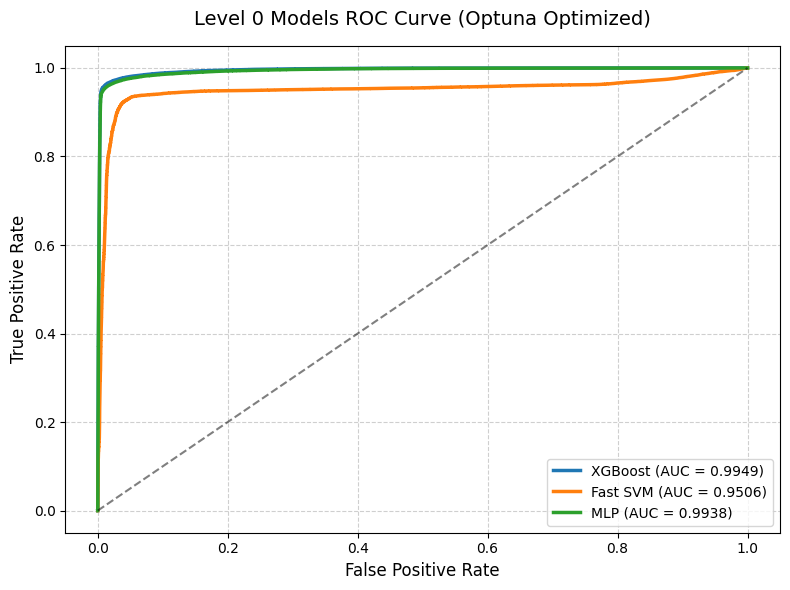

In [ ]:
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Level 0 Models ROC Curve (Optuna Optimized)", fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **100% 資料最終訓練與下載替換**

In [ ]:
print("\n[Final Stage] 使用 100% 資料訓練最終模型並匯出...")

# 1. XGBoost
print("正在訓練最終 XGBoost...")
final_models["XGBoost"].fit(X, y)
final_models["XGBoost"].save_model("optuna_xgb_final.json")
print("  ✅ 已儲存: optuna_xgb_final.json")

# 2. Fast SVM
print("正在訓練最終 Fast SVM...")
final_models["Fast SVM"].fit(X, y)
joblib.dump(final_models["Fast SVM"], "optuna_svm_final.pkl")
print("  ✅ 已儲存: optuna_svm_final.pkl")

# 3. MLP
print("正在訓練最終 MLP...")
final_models["MLP"].fit(X, y)
joblib.dump(final_models["MLP"], "optuna_mlp_final.pkl")
print("  ✅ 已儲存: optuna_mlp_final.pkl")

print("大功告成")


[Final Stage] 使用 100% 資料訓練最終模型並匯出...
正在訓練最終 XGBoost...
  ✅ 已儲存: optuna_xgb_final.json
正在訓練最終 Fast SVM...
  ✅ 已儲存: optuna_svm_final.pkl
正在訓練最終 MLP...
  ✅ 已儲存: optuna_mlp_final.pkl
大功告成
